## Header

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
path = os.path.join("data","cleaned","final_dataset.csv") 
df=pd.read_csv(path)


In [3]:
df1=pd.read_csv(path)

In [4]:
df.columns

Index(['order_id', 'order_date', 'order_year', 'order_month', 'order_day',
       'order_hour', 'order_minute', 'order_second', 'is_weekend',
       'order_status', 'customer_id', 'customer_name', 'gender', 'age',
       'customer_segment', 'country', 'city', 'customer_loyalty_score',
       'total_orders_by_customer', 'account_creation_date', 'product_id',
       'product_name', 'category', 'sub_category', 'brand',
       'product_rating_avg', 'product_reviews_count', 'stock_quantity',
       'unit_price_usd', 'quantity', 'discount_percent', 'total_price_usd',
       'cost_usd', 'profit_usd', 'tax_usd', 'payment_method', 'payment_status',
       'installment_plan', 'shipping_method', 'shipping_cost_usd',
       'delivery_days', 'shipping_country', 'warehouse_location',
       'delivery_status', 'device_type', 'warehouse_id', 'inventory_id'],
      dtype='object')

## Order & Customer

In [5]:
temp=['order_id', 'order_date', 'order_year', 'order_month', 'order_day',
       'order_hour', 'order_minute', 'order_second', 'is_weekend',
       'order_status', 'customer_id', 'customer_name',
       'gender', 'age', 'customer_segment', 'country', 'city',
       'customer_loyalty_score', 'total_orders_by_customer',
       'account_creation_date',]
len(temp)

20

In [6]:
assigned_cols=['order_id','order_date','order_status','is_weekend',
               'customer_id','customer_name','gender','age','customer_segment',
               'country','city','customer_loyalty_score','total_orders_by_customer',
               'account_creation_date']

In [7]:
df=df[assigned_cols]

In [8]:
df.head()

,order_id,order_date,order_status,is_weekend,customer_id,customer_name,gender,age,customer_segment,country,city,customer_loyalty_score,total_orders_by_customer,account_creation_date
0,ORD-XAJI00,2024-10-14,Completed,No,CUS-6DPBH0,Drew Warren,Male,53,Regular,Netherlands,Utrecht,22.0,38,2022-04-23
1,ORD-NHJ7X0,2024-10-21,Completed,No,CUS-G0FN90,Victor Sullivan,Male,61,Regular,United States,Los Angeles,82.2,21,2022-08-22
2,ORD-YTJXE0,2025-03-17,Completed,No,CUS-Q85JS0,Jason Garcia,Male,50,VIP,France,Nice,60.9,10,2024-08-04
3,ORD-EIMVI0,2024-09-27,Completed,No,CUS-CWI640,David Norris,Male,50,Regular,Italy,Milan,53.9,47,2023-08-06
4,ORD-OR56F0,2025-05-21,Completed,No,CUS-O72KZ0,Laura Phillips,Female,27,Regular,Germany,Berlin,57.9,35,2023-01-02


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000122 entries, 0 to 1000121
Data columns (total 14 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   order_id                  1000122 non-null  object 
 1   order_date                1000122 non-null  object 
 2   order_status              1000122 non-null  object 
 3   is_weekend                1000122 non-null  object 
 4   customer_id               1000122 non-null  object 
 5   customer_name             1000122 non-null  object 
 6   gender                    1000122 non-null  object 
 7   age                       1000122 non-null  int64  
 8   customer_segment          1000122 non-null  object 
 9   country                   1000122 non-null  object 
 10  city                      1000122 non-null  object 
 11  customer_loyalty_score    1000122 non-null  float64
 12  total_orders_by_customer  1000122 non-null  int64  
 13  account_creation_date     1

In [10]:
df.loc[df['order_id'].duplicated(False)].sort_values(by='order_id').head(10)

,order_id,order_date,order_status,is_weekend,customer_id,customer_name,gender,age,customer_segment,country,city,customer_loyalty_score,total_orders_by_customer,account_creation_date


In [11]:
df.loc[df['customer_id'].duplicated(False)].sort_values(by='customer_id').head(10)

,order_id,order_date,order_status,is_weekend,customer_id,customer_name,gender,age,customer_segment,country,city,customer_loyalty_score,total_orders_by_customer,account_creation_date


In [12]:
df['customer_name'].nunique()

330156

In [13]:
df[['customer_id','customer_name']].groupby('customer_name').count()

,customer_id
customer_name,
Aaron Abbott,4
Aaron Acevedo,2
Aaron Acosta,1
Aaron Acosta MD,1
Aaron Adams,12
...,...
Zoe Wilson,4
Zoe Winters,1
Zoe Wright,2


In [14]:
df[df['customer_name']=='Aaron Adams']

,order_id,order_date,order_status,is_weekend,customer_id,customer_name,gender,age,customer_segment,country,city,customer_loyalty_score,total_orders_by_customer,account_creation_date
56257,ORD-DJGZM0,2025-02-02,Completed,Yes,CUS-7VHQ90,Aaron Adams,Male,37,Premium,United Kingdom,Leeds,90.6,44,2023-06-30
111915,ORD-ZB5X00,2025-04-14,Pending,No,CUS-H7L6V0,Aaron Adams,Male,42,Premium,Germany,Hamburg,67.0,11,2023-09-27
276981,ORD-F4WWJ0,2025-11-09,Pending,Yes,CUS-NKN1W0,Aaron Adams,Male,34,Regular,Canada,Vancouver,1.1,39,2025-02-04
301828,ORD-39DC30,2025-10-19,Cancelled,Yes,CUS-25O3U0,Aaron Adams,Male,21,Premium,United Kingdom,Manchester,86.2,30,2025-05-11
309763,ORD-C4C2K0,2025-07-04,Returned,No,CUS-QCYQO0,Aaron Adams,Male,31,Regular,Australia,Sydney,12.3,29,2021-05-07
396788,ORD-Z0EOC0,2024-08-22,Completed,No,CUS-O8A9B0,Aaron Adams,Male,27,Regular,Spain,Barcelona,90.0,12,2023-03-30
632687,ORD-XRCDQ0,2025-03-02,Completed,Yes,CUS-H66EV0,Aaron Adams,Male,40,Regular,France,Marseille,68.6,28,2022-03-26
670732,ORD-9R4H30,2025-07-24,Completed,No,CUS-NPF8I0,Aaron Adams,Male,33,Premium,Canada,Calgary,8.8,23,2025-02-16
756343,ORD-PMWP80,2026-01-26,Completed,No,CUS-725O60,Aaron Adams,Male,31,Regular,Italy,Naples,56.2,48,2022-10-19
775556,ORD-JKMU20,2025-09-19,Cancelled,No,CUS-4KTQS0,Aaron Adams,Male,47,Regular,France,Marseille,63.5,27,2022-02-09


In [15]:
df.shape[0]

1000122

In [16]:
df['order_date']=pd.to_datetime(df['order_date'])

In [17]:
df['order_status'].unique()

array(['Completed', 'Returned', 'Pending', 'Cancelled', 'Processing'],
      dtype=object)

<Axes: xlabel='order_status'>

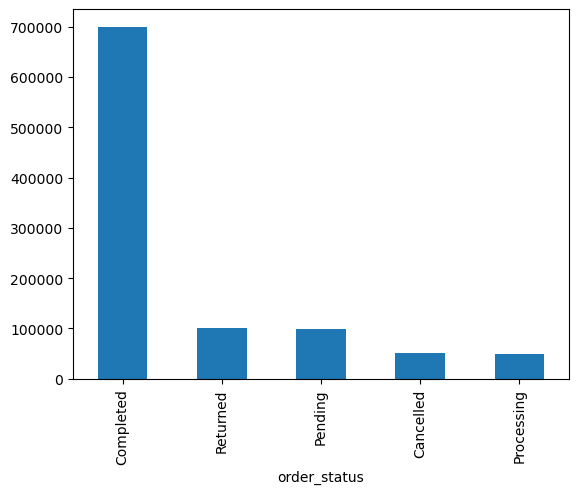

In [18]:
df['order_status'].value_counts().plot(kind='bar')

In [19]:
df['is_weekend'].unique()

array(['No', 'Yes'], dtype=object)

[Text(0, 3, '713020'), Text(0, 3, '287102')]

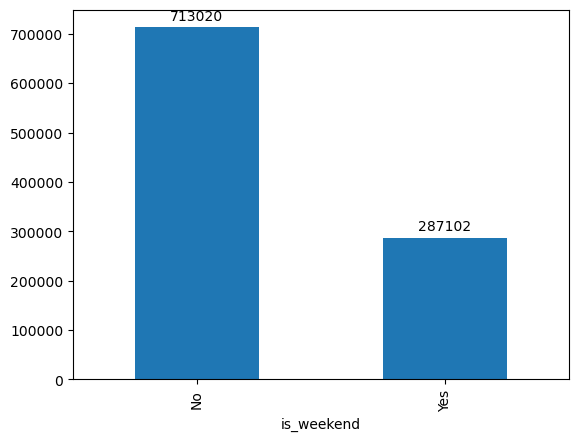

In [20]:
ax=df['is_weekend'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0], padding=3)

In [21]:
df['customer_name'].nunique()

330156

In [22]:
df['gender'].unique()

array(['Male', 'Female'], dtype=object)

[Text(0, 3, '500180'), Text(0, 3, '499942')]

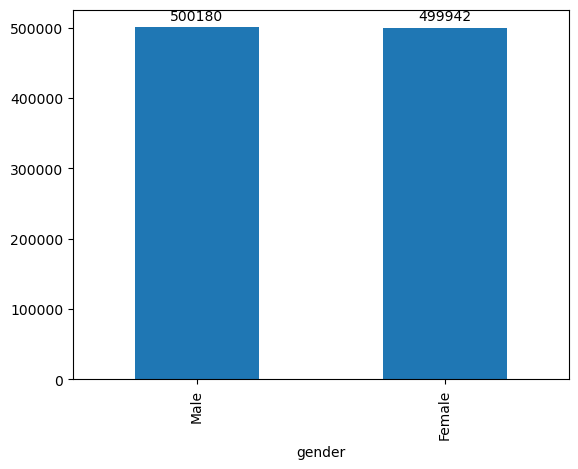

In [23]:
ax=df['gender'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0], padding=3)

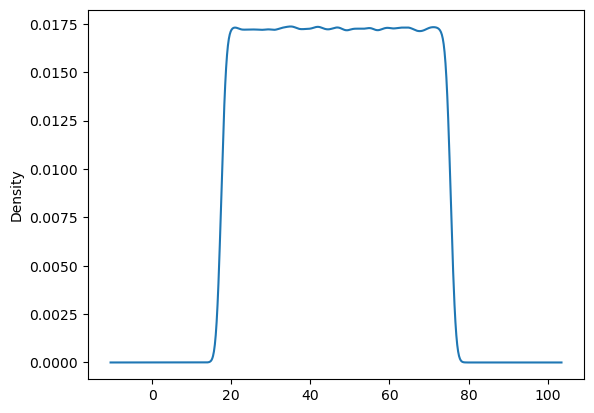

In [24]:
df['age'].plot(kind='kde')
plt.show()

In [25]:
df['customer_segment'].unique()

array(['Regular', 'VIP', 'Premium'], dtype=object)

<Axes: xlabel='customer_segment'>

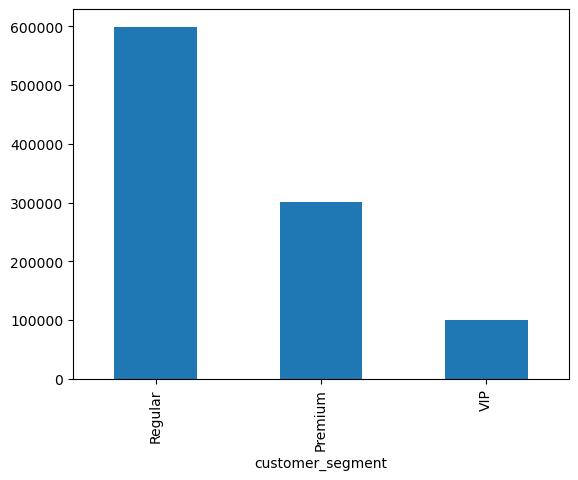

In [26]:
df['customer_segment'].value_counts().plot(kind='bar')

In [27]:
df['country'].unique()

array(['Netherlands', 'United States', 'France', 'Italy', 'Germany',
       'Canada', 'Australia', 'Belgium', 'United Kingdom', 'Spain'],
      dtype=object)

[Text(0, 0, '100548'),
 Text(0, 0, '100357'),
 Text(0, 0, '100146'),
 Text(0, 0, '100064'),
 Text(0, 0, '100041'),
 Text(0, 0, '100023'),
 Text(0, 0, '99774'),
 Text(0, 0, '99761'),
 Text(0, 0, '99742'),
 Text(0, 0, '99666')]

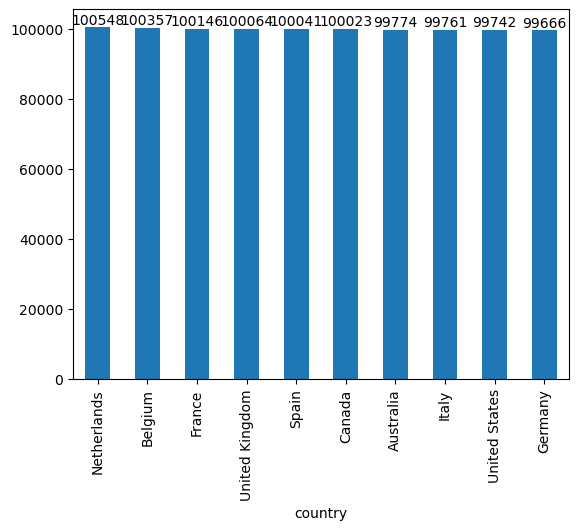

In [28]:
ax=df['country'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0])

In [29]:
df['city'].nunique()

50

<Axes: xlabel='city'>

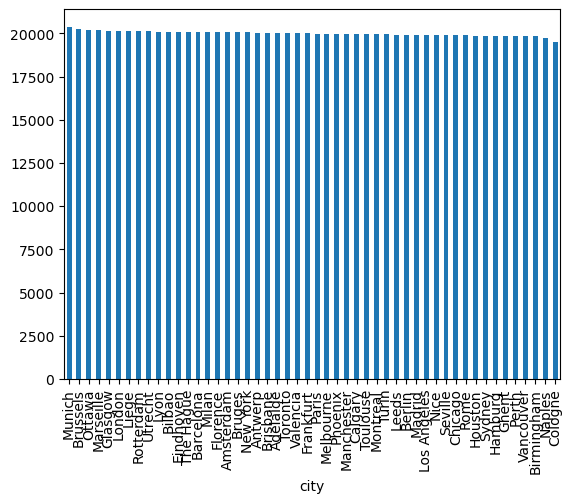

In [30]:
df['city'].value_counts().plot(kind='bar')

In [31]:
df['customer_loyalty_score'].describe()

count    1.000122e+06
mean     4.997250e+01
std      2.889377e+01
min      0.000000e+00
25%      2.490000e+01
50%      5.000000e+01
75%      7.500000e+01
max      1.000000e+02
Name: customer_loyalty_score, dtype: float64

<Axes: ylabel='Density'>

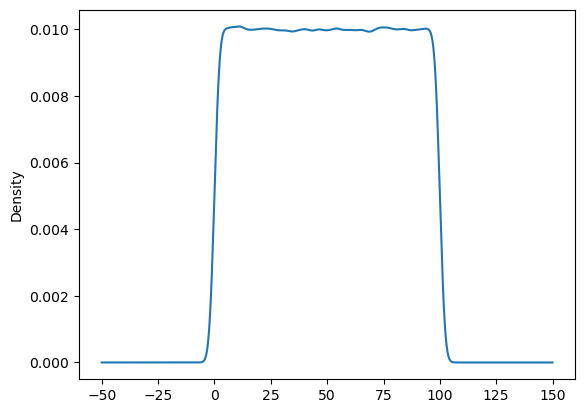

In [32]:
df['customer_loyalty_score'].plot(kind='kde')

In [33]:
df['total_orders_by_customer'].describe()

count    1.000122e+06
mean     2.548701e+01
std      1.443422e+01
min      1.000000e+00
25%      1.300000e+01
50%      2.500000e+01
75%      3.800000e+01
max      5.000000e+01
Name: total_orders_by_customer, dtype: float64

<Axes: ylabel='Density'>

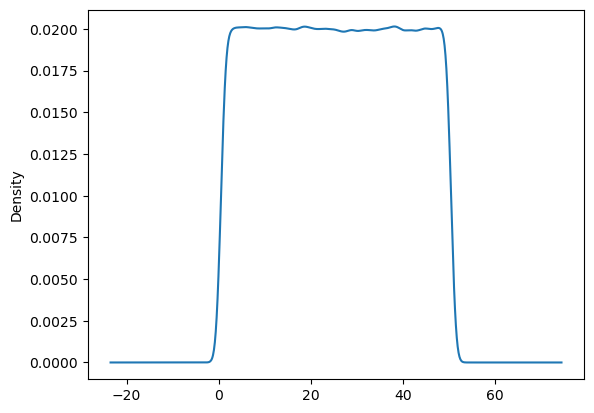

In [34]:
df['total_orders_by_customer'].plot(kind='kde')

In [35]:
df['account_creation_date'].nunique()

1826

In [36]:
df['account_creation_date']=pd.to_datetime(df['account_creation_date'])

<Axes: xlabel='order_date'>

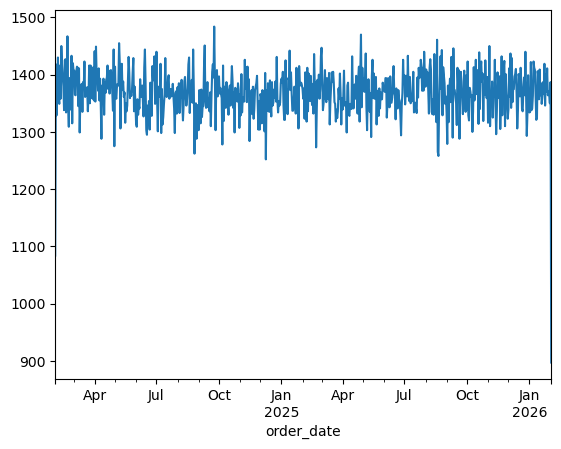

In [37]:
order_counts = df.groupby(df['order_date'].dt.to_period("D")).size()

order_counts.plot(kind='line')

In [38]:
df[['customer_id','customer_name']].groupby('customer_id').count()['customer_name'].unique()

array([1])

In [39]:
df[['order_id','order_date']].groupby('order_id').count()['order_date'].unique()

array([1])

In [46]:
df1.columns

Index(['order_id', 'order_date', 'order_year', 'order_month', 'order_day',
       'order_hour', 'order_minute', 'order_second', 'is_weekend',
       'order_status', 'customer_id', 'customer_name', 'gender', 'age',
       'customer_segment', 'country', 'city', 'customer_loyalty_score',
       'total_orders_by_customer', 'account_creation_date', 'product_id',
       'product_name', 'category', 'sub_category', 'brand',
       'product_rating_avg', 'product_reviews_count', 'stock_quantity',
       'unit_price_usd', 'quantity', 'discount_percent', 'total_price_usd',
       'cost_usd', 'profit_usd', 'tax_usd', 'payment_method', 'payment_status',
       'installment_plan', 'shipping_method', 'shipping_cost_usd',
       'delivery_days', 'shipping_country', 'warehouse_location',
       'delivery_status', 'device_type', 'warehouse_id', 'inventory_id'],
      dtype='object')

In [51]:
df1[['order_date','warehouse_id','inventory_id','product_id','quantity','stock_quantity','customer_loyalty_score']].groupby(['order_date','warehouse_id','inventory_id','product_id']).agg(
        average_loyality_score=('customer_loyalty_score', 'mean'),
        total_stock_quantity=('stock_quantity', 'sum'),
        total_quantity_ordered=('quantity', 'sum')).reset_index()

,order_date,warehouse_id,inventory_id,product_id,average_loyality_score,total_stock_quantity,total_quantity_ordered
0,2024-02-03,10101,101,38,92.80,13,2
1,2024-02-03,10101,112,45,51.90,1067,6
2,2024-02-03,10101,115,20,11.10,598,3
3,2024-02-03,10101,115,47,64.20,333,2
4,2024-02-03,10101,119,21,40.60,1854,10
...,...,...,...,...,...,...,...
760002,2026-02-02,50350,507,2,48.05,1272,10
760003,2026-02-02,50350,509,12,78.40,163,2
760004,2026-02-02,50350,509,18,57.00,629,1
760005,2026-02-02,50350,509,41,39.50,795,3


In [52]:
df1.shape

(1000122, 47)